# Notebook 5: Tensor Networks, DMRG & Time Evolution

This notebook covers Qforge's tensor network simulation backends for reaching **50-1000+ qubits** — far beyond exact state vector limits.

1. **MPS** (Matrix Product States) — simulate low-entanglement circuits with 50+ qubits
2. **DMRG** — find ground states of 1D Hamiltonians (Heisenberg, Ising, XXZ, custom)
3. **Custom Hamiltonians** — build arbitrary MPO Hamiltonians with `MPOBuilder`
4. **Excited States** — find multiple eigenstates via the penalty method
5. **TEBD** — real-time and imaginary-time evolution on finite MPS
6. **iTEBD** — ground states and dynamics of infinite 1D systems
7. **Distributed Simulation** — MPI-sharded state vectors for 30-40 qubits

In [1]:
import numpy as np
import matplotlib.pyplot as plt

---
## 1. Matrix Product States (MPS)

An MPS represents an n-qubit state as a chain of small tensors instead of a single 2^n vector. For states with limited entanglement (e.g., ground states of local Hamiltonians), this is exponentially more efficient.

**Key parameter**: bond dimension `chi` — controls the maximum entanglement the MPS can represent. Larger chi = more accurate but slower.

| chi | Entanglement capacity | Typical use |
|-----|----------------------|-------------|
| 1   | Product states only  | Classical states |
| 2-8 | Low entanglement     | Shallow circuits, GHZ |
| 16-64 | Moderate           | DMRG ground states |
| 128-512 | High             | Critical systems, deep circuits |

In [2]:
from qforge.mps import MatrixProductState
from qforge.gates import H, CNOT, RY, RZ, X

# Create a 50-qubit MPS (impossible with state vectors!)
psi = MatrixProductState(n_qubits=50, max_bond_dim=64)

# Build a GHZ state: H on qubit 0, then CNOT cascade
H(psi, 0)
for i in range(49):
    CNOT(psi, i, i + 1)

print(f"50-qubit GHZ state created")
print(f"Bond dimensions: {psi.bond_dimensions()[:5]}... (all should be 2)")
print(f"Entanglement entropy at bond 0: {psi.entanglement_entropy(0):.4f} bits")
print(f"Max entanglement: {psi.max_entanglement():.4f} bits")
print(f"Norm: {psi.norm():.8f}")

50-qubit GHZ state created
Bond dimensions: [2, 2, 2, 2, 2]... (all should be 2)
Entanglement entropy at bond 0: 1.0000 bits
Max entanglement: 1.0000 bits
Norm: 1.00000000


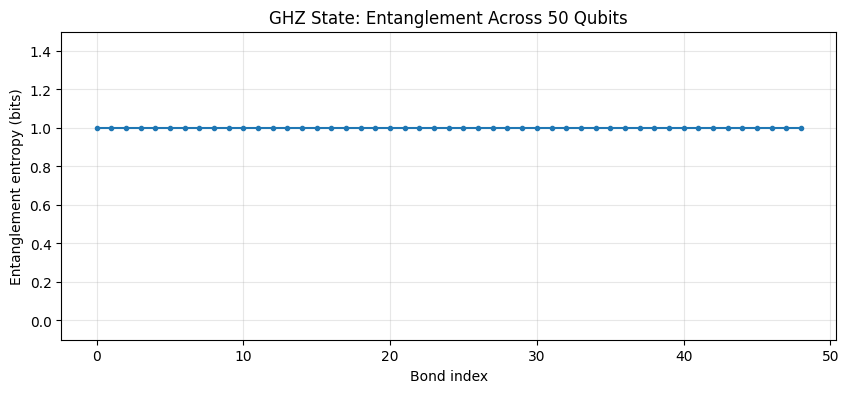

In [3]:
# Entanglement entropy profile across all bonds
n = 50
entropies = [psi.entanglement_entropy(b) for b in range(n - 1)]

plt.figure(figsize=(10, 4))
plt.plot(range(n - 1), entropies, 'o-', markersize=3)
plt.xlabel('Bond index')
plt.ylabel('Entanglement entropy (bits)')
plt.title('GHZ State: Entanglement Across 50 Qubits')
plt.ylim(-0.1, 1.5)
plt.grid(True, alpha=0.3)
plt.show()

In [6]:
# try some local gates and see how the entanglement changes
RY(psi, 0, np.pi / 4)  # Rotate qubit 0 by 45 degrees
print(f"After RY on qubit 0:")
print(f"Entanglement entropy at bond 0: {psi.entanglement_entropy(0):.4f} bits")
print(f"Max entanglement: {psi.max_entanglement():.4f} bits")
print(f"Norm: {psi.norm():.8f}")

After RY on qubit 0:
Entanglement entropy at bond 0: 1.0000 bits
Max entanglement: 1.0000 bits
Norm: 1.00000000


In [7]:
# try some more gates
RZ(psi, 1, np.pi / 2)  # Rotate qubit 1 around Z by 90 degrees
X(psi, 2)  # Flip qubit 2
print(f"After RZ on qubit 1 and X on qubit 2:")
print(f"Entanglement entropy at bond 0: {psi.entanglement_entropy(0):.4f} bits")
print(f"Max entanglement: {psi.max_entanglement():.4f} bits")
print(f"Norm: {psi.norm():.8f}")


After RZ on qubit 1 and X on qubit 2:
Entanglement entropy at bond 0: 1.0000 bits
Max entanglement: 1.0000 bits
Norm: 1.00000000
